In [2]:
import torch, os, math, gzip, pickle
import matplotlib.pyplot as plt
from urllib.request import urlretrieve
from pathlib import Path

from torch import tensor
import torchvision as tv
import torchvision.transforms.functional as tvf
from torchvision import io

In [3]:
path_img = Path('puppy.jpg')
if not path_img.exists(): urlretrieve(url, path_img)

In [4]:
img = io.read_image('puppy.jpg')
print(img.shape)
img[:2,:3,:4]

torch.Size([3, 965, 800])


tensor([[[9, 9, 7, 6],
         [9, 8, 7, 6],
         [9, 8, 7, 6]],

        [[9, 9, 7, 6],
         [9, 8, 7, 6],
         [9, 8, 7, 6]]], dtype=torch.uint8)

In [5]:
def show_img(x, figsize=(4,3), **kwargs):
    plt.figure(figsize=figsize)
    plt.axis('off')
    if len(x.shape)==3: x = x.permute(1,2,0)  # CHW -> HWC
    plt.imshow(x.cpu(), **kwargs)

In [6]:
img2 = tvf.resize(img, 150, antialias=True)
ch,h,w = img2.shape
ch,h,w,h*w

(3, 180, 150, 27000)

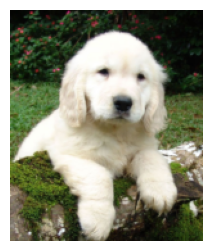

In [7]:
show_img(img2)

In [8]:
def rgb_grey(x):
    c,h,w = x.shape
    n = h*w

    x = x.flatten()
    res = torch.empty(n, dtype=x.dtype, device=x.device)
    for i in range(n): res[i] = 0.2989*x[i] + 0.5870*x[i+n] + 0.1140*x[i+2*n]
    return res.view(h, w)

In [9]:
%%time
img_g = rgb_grey(img2)

CPU times: total: 3.08 s
Wall time: 3.26 s


In [10]:
def run_kernel(f, times, *args):
    for i in range(times): f(i, *args)


def rgb_grey_k(i, x, out, n):
    out[i] = x[i] = 0.2989*x[i] + 0.5870*x[i+n] + 0.1140*x[i+2*n]

def rgb_grey_pykernel(x):
    c,h,w = x.shape
    n=h*w
    x = x.flatten()
    res = torch.empty(n, dtype=x.dtype, device=x.device)
    run_kernel(rgb_grey_k, h*w, x, res, n)
    return res.view(h, w)

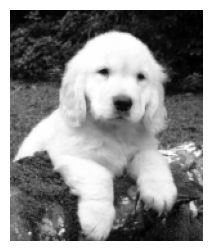

In [11]:
img_g = rgb_grey_pykernel(img2)
show_img(img_g, cmap='gray')

In [12]:
def blk_kernel(f, blocks, threads, *args):
    for i in range(blocks):
        for j in range(threads):
            f(i, j, threads, *args)

def rgb_grey_blk(blockidx, threadidx, blockdim, x, out, n):
    i = blockidx*blockdim + threadidx
    if i < n: out[i] = 0.2989*x[i] + 0.5870*x[i+n] + 0.1140*x[i+2*n]

def rgb_grey_pykernel(x):
    c,h,w = x.shape
    n=w*h
    x=x.flatten()
    res = torch.empty(n, dtype=x.dtype, device=x.device)
    threads = 256
    blocks = int(math.ceil((h*w)/threads))
    blk_kernel(rgb_grey_blk, blocks, threads, x, res, n)
    return res.view(h,w)

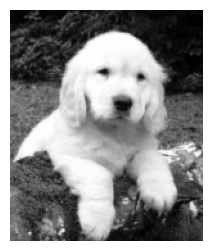

In [13]:
img_g = rgb_grey_pykernel(img2)
show_img(img_g, cmap='gray')

In [14]:
from cuda_utils import load_cuda, cuda_begin

In [25]:
cuda_src = cuda_begin + r'''
__global__ void rgb_to_grayscale_kernel(unsigned char* x, unsigned char* out, int n) {
    int i = blockIdx.x*blockDim.x + threadIdx.x;
    if (i<n) out[i] = 0.2989*x[i] + 0.5870*x[i+n] + 0.1140*x[i+2*n];
}

torch::Tensor rgb_to_grayscale(torch::Tensor input) {
    CHECK_INPUT(input);
    int h = input.size(1);
    int w = input.size(2);
    printf("h*w: %d*%d\n", h, w);
    auto output = torch::empty({h,w}, input.options());
    int threads = 256;
    rgb_to_grayscale_kernel<<<cdiv(w*h,threads), threads>>>(
        input.data_ptr<unsigned char>(), output.data_ptr<unsigned char>(), w*h);
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    return output;
}'''

In [26]:
cpp_src = "torch::Tensor rgb_to_grayscale(torch::Tensor input);"

In [27]:
module = load_cuda(cuda_src, cpp_src, ['rgb_to_grayscale'])
print(module)

<module 'inline_ext' from 'C:\\Users\\derek\\AppData\\Local\\torch_extensions\\torch_extensions\\Cache\\py313_cu126\\inline_ext\\inline_ext.pyd'>


In [28]:
dir(module)

['__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'add_one']

In [29]:
imgc = img.contiguous().cuda()

In [31]:
%%time
res = module.rgb_to_grayscale(imgc).cpu()
h,w = res.shape
h,w,h*w

AttributeError: module 'inline_ext' has no attribute 'rgb_to_grayscale'